In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

first_drop  = pd.read_csv("../../model_v1/first_drop.csv",  index_col=0)
later_drops = pd.read_csv("../../model_v1/later_drops.csv", index_col=0)

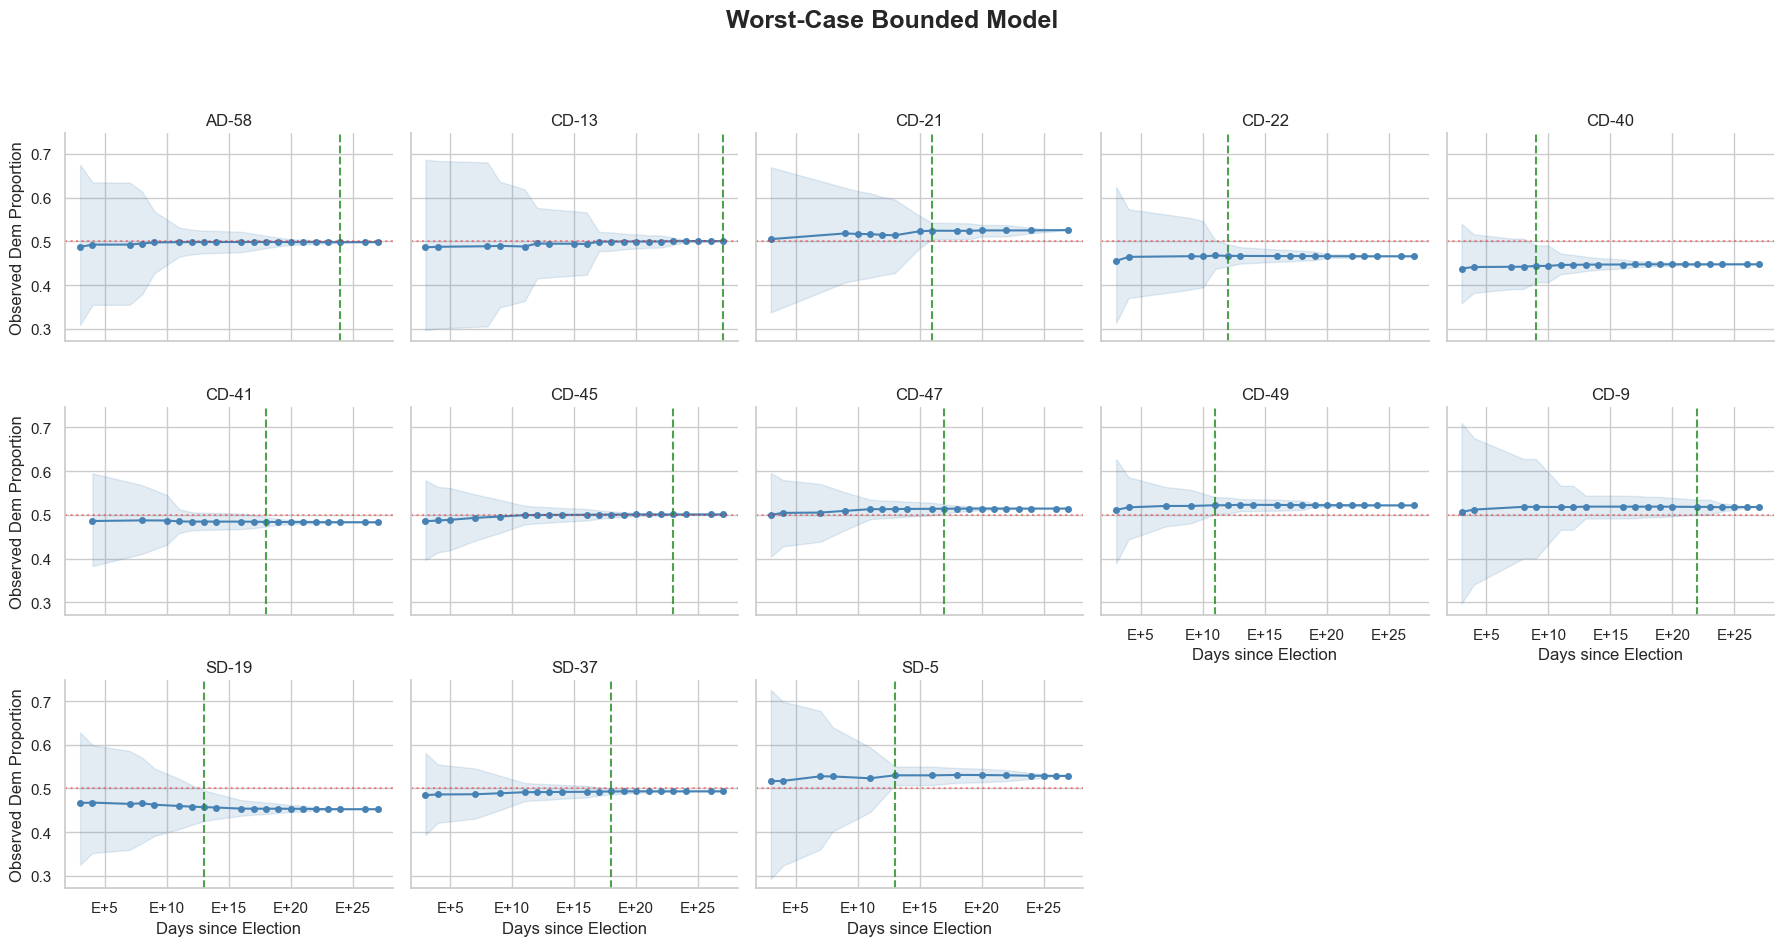

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.patches as mpatches

races = sorted(later_drops['Race'].unique())

first_drop_D     = dict(zip(first_drop['Race'], first_drop['D']))
first_drop_total = dict(zip(first_drop['Race'], first_drop['Total Votes Cast']))

cum_rows = []
for race in races:
    rd = later_drops[later_drops['Race'] == race].sort_values('Batch_ID')

    cum_D     = first_drop_D[race]     + rd['New_D'].cumsum()
    cum_total = first_drop_total[race] + rd['New_Total'].cumsum()
    remaining = rd['Votes_Remaining'].values

    for bid, d, t, r in zip(rd['Batch_ID'], cum_D, cum_total, remaining):
        final_total = t + r
        cum_rows.append({
            'Race':          race,
            'Batch_ID':      bid,
            'cum_dem_share': d / t,
            'worst_dem':     d / final_total,
            'best_dem':      (d + r) / final_total,
        })

cum_df = pd.DataFrame(cum_rows)

# Y-axis range: zoom to the actual data, not the full 0-1 scale
y_min = cum_df[['worst_dem', 'best_dem', 'cum_dem_share']].min().min()
y_max = cum_df[['worst_dem', 'best_dem', 'cum_dem_share']].max().max()
margin = (y_max - y_min) * 0.05
ylim = (y_min - margin, y_max + margin)

def plot_cum_share(data, **kwargs):
    ax = plt.gca()
    
    # 1. Plot the worst/best case bounds
    ax.fill_between(data['Batch_ID'], data['worst_dem'], data['best_dem'],
                    alpha=0.15, color='steelblue')
    
    # 2. Plot the cumulative share
    ax.plot(data['Batch_ID'], data['cum_dem_share'],
            color='steelblue', marker='o', markersize=4)
    
    # 3. Add 50% tie line
    ax.axhline(0.5, color='red', linestyle=':', alpha=0.4)
    
    # --- NEW: Check for mathematically decided races ---
    # Decided if worst case > 50% (Dem win) OR best case < 50% (Rep win)
    decided_mask = (data['worst_dem'] > 0.5) | (data['best_dem'] < 0.5)
    
    if decided_mask.any():
        # Find the first day (Batch_ID) where the race becomes mathematically impossible to lose
        first_decided_day = data.loc[decided_mask, 'Batch_ID'].iloc[0]
        
        # Draw a vertical line at that day
        ax.axvline(x=first_decided_day, color='forestgreen', linestyle='--', alpha=0.8, linewidth=1.5)

    # Format X-axis
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'E+{int(x)}'))

sns.set_theme(style='whitegrid')
g = sns.FacetGrid(cum_df, col='Race', col_wrap=5,
                  sharey=True, height=3, aspect=1.2)
g.map_dataframe(plot_cum_share)
g.set(ylim=ylim)
g.set_axis_labels('Days since Election', 'Observed Dem Proportion')
g.set_titles(col_template='{col_name}')

g.fig.suptitle('Worst-Case Bounded Model', fontsize=18, fontweight='bold', y=1.05)

# --- NEW: Added 'Mathematically Decided' to the legend handles ---
handles = [
    plt.Line2D([0], [0], color='steelblue', marker='o', markersize=4, label='Cumulative D/(D+R)'),
    mpatches.Patch(color='steelblue', alpha=0.15, label='Worst-case range'),
    plt.Line2D([0], [0], color='red', linestyle=':', alpha=0.4, label='50% Tie'),
    plt.Line2D([0], [0], color='forestgreen', linestyle='--', alpha=0.8, label='Math. Decided')
]

plt.tight_layout()
plt.show()

── Coverage & Race Calls ───────────────────────────────────────────────
Interval coverage (all batches, all races): 100% (guaranteed by construction)

 Race  Final Dem Share Winner  First Call Batch
CD-40           0.4474      R                 9
CD-49           0.5217      D                11
CD-22           0.4658      R                12
SD-19           0.4524      R                13
 SD-5           0.5286      D                13
CD-21           0.5257      D                16
CD-47           0.5144      D                17
CD-41           0.4831      R                18
SD-37           0.4934      R                18
 CD-9           0.5179      D                22
CD-45           0.5010      D                23
AD-58           0.4981      R                24
CD-13           0.5004      D                27


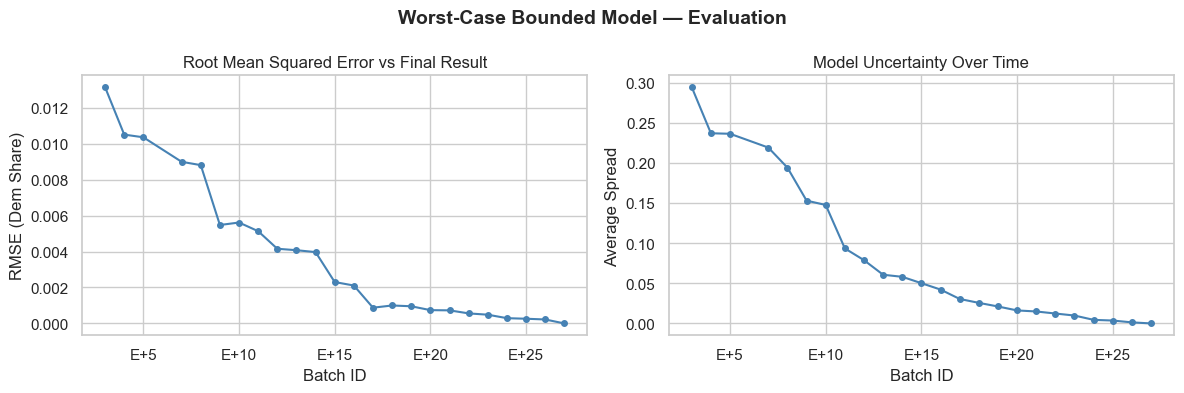

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Ground truth: final dem share = cum_dem_share at the last available batch ──
final_result = (
    cum_df.sort_values('Batch_ID')
    .groupby('Race')
    .last()['cum_dem_share']
    .rename('final_dem')
)

# ── Coverage & first-call batch ───────────────────────────────────────────────
call_rows = []
for race, grp in cum_df.groupby('Race'):
    callable_batches = grp[(grp['worst_dem'] > 0.5) | (grp['best_dem'] < 0.5)]
    call_batch = int(callable_batches['Batch_ID'].min()) if len(callable_batches) else None
    final = final_result.loc[race]
    call_rows.append({
        'Race':             race,
        'Final Dem Share':  round(final, 4),
        'Winner':           'D' if final > 0.5 else 'R',
        'First Call Batch': call_batch if call_batch else 'Never called',
    })

call_df = pd.DataFrame(call_rows).sort_values('First Call Batch')
print("── Coverage & Race Calls ───────────────────────────────────────────────")
print(f"Interval coverage (all batches, all races): 100% (guaranteed by construction)\n")
print(call_df.to_string(index=False))

# ── Create Forward-Filled Matrices for Daily Metrics ──────────────────────────
# Calculate interval width
cum_df['interval_width'] = cum_df['best_dem'] - cum_df['worst_dem']

# Pivot data so Rows = Batch_ID and Columns = Races
point_est_matrix = cum_df.pivot(index='Batch_ID', columns='Race', values='cum_dem_share')
width_matrix = cum_df.pivot(index='Batch_ID', columns='Race', values='interval_width')

# Forward-fill missing values to carry over the previous day's state
point_est_matrix = point_est_matrix.ffill()
width_matrix = width_matrix.ffill()

# ── RMSE of point estimate (cum_dem_share) vs final result ────────────────────
# Subtract final results from the entire matrix (Pandas automatically aligns the Race columns)
squared_errors = (point_est_matrix - final_result) ** 2

# Calculate mean across rows (races), then take the square root
rmse_series = np.sqrt(squared_errors.mean(axis=1))
rmse_df = rmse_series.reset_index(name='RMSE')

# ── Model Uncertainty (Interval Width) ────────────────────────────────────────
# Calculate the mean interval width across all races for each day
width_series = width_matrix.mean(axis=1)
width_df = width_series.reset_index(name='Mean_Interval_Width')

# ── Plot Performance ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left Plot: RMSE
axes[0].plot(rmse_df['Batch_ID'], rmse_df['RMSE'], color='steelblue', marker='o', markersize=4)
axes[0].set_title('Root Mean Squared Error vs Final Result')
axes[0].set_xlabel('Batch ID')
axes[0].set_ylabel('RMSE (Dem Share)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'E+{int(x)}'))

# Right Plot: Uncertainty/Spread
axes[1].plot(width_df['Batch_ID'], width_df['Mean_Interval_Width'], color='steelblue', marker='o', markersize=4)
axes[1].set_title('Model Uncertainty Over Time')
axes[1].set_xlabel('Batch ID')
axes[1].set_ylabel('Average Spread')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'E+{int(x)}'))

plt.suptitle('Worst-Case Bounded Model — Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
call_df["First Call Batch"].mean()

np.float64(17.153846153846153)

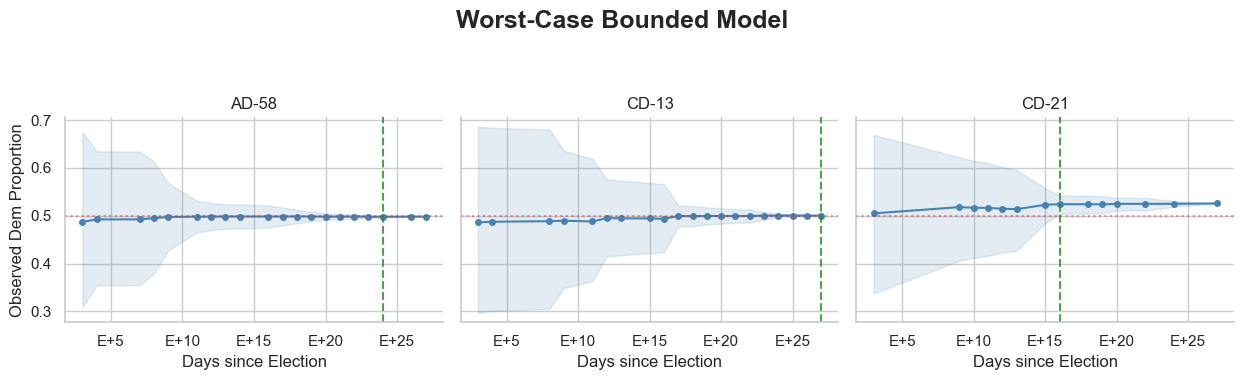

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.patches as mpatches

# --- CHANGED: Grab only the first 3 sorted races ---
races = sorted(later_drops['Race'].unique())[:3]

first_drop_D     = dict(zip(first_drop['Race'], first_drop['D']))
first_drop_total = dict(zip(first_drop['Race'], first_drop['Total Votes Cast']))

cum_rows = []
# This loop now only processes the 3 races we selected above
for race in races:
    rd = later_drops[later_drops['Race'] == race].sort_values('Batch_ID')

    cum_D     = first_drop_D[race]     + rd['New_D'].cumsum()
    cum_total = first_drop_total[race] + rd['New_Total'].cumsum()
    remaining = rd['Votes_Remaining'].values

    for bid, d, t, r in zip(rd['Batch_ID'], cum_D, cum_total, remaining):
        final_total = t + r
        cum_rows.append({
            'Race':          race,
            'Batch_ID':      bid,
            'cum_dem_share': d / t,
            'worst_dem':     d / final_total,
            'best_dem':      (d + r) / final_total,
        })

cum_df = pd.DataFrame(cum_rows)

# Y-axis range: zoom to the actual data, not the full 0-1 scale
y_min = cum_df[['worst_dem', 'best_dem', 'cum_dem_share']].min().min()
y_max = cum_df[['worst_dem', 'best_dem', 'cum_dem_share']].max().max()
margin = (y_max - y_min) * 0.05
ylim = (y_min - margin, y_max + margin)

def plot_cum_share(data, **kwargs):
    ax = plt.gca()
    
    # Plot the worst/best case bounds
    ax.fill_between(data['Batch_ID'], data['worst_dem'], data['best_dem'],
                    alpha=0.15, color='steelblue')
    
    # Plot the cumulative share
    ax.plot(data['Batch_ID'], data['cum_dem_share'],
            color='steelblue', marker='o', markersize=4)
    
    # Add 50% tie line
    ax.axhline(0.5, color='red', linestyle=':', alpha=0.4)
    
    # Check for mathematically decided races
    decided_mask = (data['worst_dem'] > 0.5) | (data['best_dem'] < 0.5)
    
    if decided_mask.any():
        # Find the first day (Batch_ID) where the race becomes mathematically impossible to lose
        first_decided_day = data.loc[decided_mask, 'Batch_ID'].iloc[0]
        
        # Draw a vertical line at that day
        ax.axvline(x=first_decided_day, color='forestgreen', linestyle='--', alpha=0.8, linewidth=1.5)

    # Format X-axis
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'E+{int(x)}'))

sns.set_theme(style='whitegrid')

# --- CHANGED: col_wrap set to 3 so they fit perfectly in one row ---
g = sns.FacetGrid(cum_df, col='Race', col_wrap=3,
                  sharey=True, height=3.5, aspect=1.2)

g.map_dataframe(plot_cum_share)
g.set(ylim=ylim)
g.set_axis_labels('Days since Election', 'Observed Dem Proportion')
g.set_titles(col_template='{col_name}')

g.fig.suptitle('Worst-Case Bounded Model', fontsize=18, fontweight='bold', y=1.08)

handles = [
    plt.Line2D([0], [0], color='steelblue', marker='o', markersize=4, label='Cumulative D/(D+R)'),
    mpatches.Patch(color='steelblue', alpha=0.15, label='Worst-case range'),
    plt.Line2D([0], [0], color='red', linestyle=':', alpha=0.4, label='50% Tie'),
    plt.Line2D([0], [0], color='forestgreen', linestyle='--', alpha=0.8, label='Math. Decided')
]

plt.tight_layout()
plt.show()